# Bellabeat Fitness Data Analysis – Pandas

This analysis explores user activity patterns using the Bellabeat fitness dataset.
The objective is to understand daily movement trends, sedentary behavior,
activity intensity distribution, and relationships between steps and calorie expenditure.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 1. Data Loading

The dataset is loaded into a Pandas DataFrame for analysis.

In [23]:
df = pd.read_csv("/dailyActivity_merged.csv")
display(df.head())

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories
0,1503960366,4/12/2016,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985
1,1503960366,4/13/2016,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797
2,1503960366,4/14/2016,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776
3,1503960366,4/15/2016,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745
4,1503960366,4/16/2016,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

The dataset contains 940 daily records and 15 columns.
All columns contain non-null values, indicating no missing data issues.

The dataset includes information such as:
- Total Steps
- Calories Burned
- Activity Minutes (Light, Fairly, Very Active)
- Sedentary Minutes

## Data Understanding

This section explores the structure of the dataset and provides an overview of the available variables including steps, activity minutes, distance, and calories burned.

In [25]:
df.shape

(940, 15)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 940 entries, 0 to 939
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Id                        940 non-null    int64  
 1   ActivityDate              940 non-null    object 
 2   TotalSteps                940 non-null    int64  
 3   TotalDistance             940 non-null    float64
 4   TrackerDistance           940 non-null    float64
 5   LoggedActivitiesDistance  940 non-null    float64
 6   VeryActiveDistance        940 non-null    float64
 7   ModeratelyActiveDistance  940 non-null    float64
 8   LightActiveDistance       940 non-null    float64
 9   SedentaryActiveDistance   940 non-null    float64
 10  VeryActiveMinutes         940 non-null    int64  
 11  FairlyActiveMinutes       940 non-null    int64  
 12  LightlyActiveMinutes      940 non-null    int64  
 13  SedentaryMinutes          940 non-null    int64  
 14  Calories  

In [27]:
df.isnull().sum()

,0
Id,0
ActivityDate,0
TotalSteps,0
TotalDistance,0
TrackerDistance,0
LoggedActivitiesDistance,0
VeryActiveDistance,0
ModeratelyActiveDistance,0
LightActiveDistance,0
SedentaryActiveDistance,0


The dataset contains no missing values, indicating the data is complete for analysis.

In [28]:
df.duplicated().sum()

np.int64(0)

No duplicate records were found in the dataset.

## 2. Data Preparation

The ActivityDate column is converted into datetime format.
A new column named "Weekday" is created to analyze weekly activity patterns.

In [29]:
df['ActivityDate'] = pd.to_datetime(df['ActivityDate'])
df['Weekday'] = df['ActivityDate'].dt.day_name()

df.head()

,Id,ActivityDate,TotalSteps,TotalDistance,TrackerDistance,LoggedActivitiesDistance,VeryActiveDistance,ModeratelyActiveDistance,LightActiveDistance,SedentaryActiveDistance,VeryActiveMinutes,FairlyActiveMinutes,LightlyActiveMinutes,SedentaryMinutes,Calories,Weekday
0,1503960366,2016-04-12,13162,8.50,8.50,0.0,1.88,0.55,6.06,0.0,25,13,328,728,1985,Tuesday
1,1503960366,2016-04-13,10735,6.97,6.97,0.0,1.57,0.69,4.71,0.0,21,19,217,776,1797,Wednesday
2,1503960366,2016-04-14,10460,6.74,6.74,0.0,2.44,0.40,3.91,0.0,30,11,181,1218,1776,Thursday
3,1503960366,2016-04-15,9762,6.28,6.28,0.0,2.14,1.26,2.83,0.0,29,34,209,726,1745,Friday
4,1503960366,2016-04-16,12669,8.16,8.16,0.0,2.71,0.41,5.04,0.0,36,10,221,773,1863,Saturday


## Feature Engineering

New variables are created to enhance analysis, including weekday extraction and total active minutes.

In [30]:
df['Weekday'] = df['ActivityDate'].dt.day_name()

df['TotalActiveMinutes'] = (
    df['VeryActiveMinutes']
    + df['FairlyActiveMinutes']
    + df['LightlyActiveMinutes']
)

## 3. Weekly Activity Pattern

In [31]:
weekday_steps = df.groupby('Weekday')['TotalSteps'].mean().sort_values(ascending=False)

weekday_steps

,TotalSteps
Weekday,
Saturday,8152.975806
Tuesday,8125.006579
Monday,7780.866667
Wednesday,7559.373333
Friday,7448.230159
Thursday,7405.836735
Sunday,6933.231405


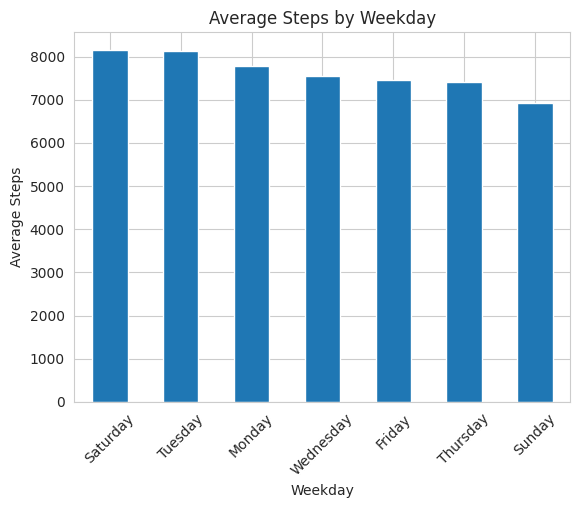

In [32]:
plt.figure()
weekday_steps.plot(kind='bar')
plt.title("Average Steps by Weekday")
plt.ylabel("Average Steps")
plt.xticks(rotation=45)
plt.show()


The bar chart shows that Saturday records the highest average steps,
while Sunday records the lowest.

This indicates increased engagement at the beginning of the weekend
and reduced activity at the end.

## 4. Sedentary vs Active Behavior

In [33]:

df['TotalActiveMinutes'] = (
    df['LightlyActiveMinutes'] +
    df['FairlyActiveMinutes'] +
    df['VeryActiveMinutes']
)

df[['SedentaryMinutes','TotalActiveMinutes']].mean()

,0
SedentaryMinutes,991.210638
TotalActiveMinutes,227.542553


On average, users spend approximately 991 minutes per day sedentary,
compared to only 227 active minutes.

This suggests that nearly 70% of daily time is inactive,
indicating a predominantly sedentary lifestyle.

## 5. Activity Intensity Distribution

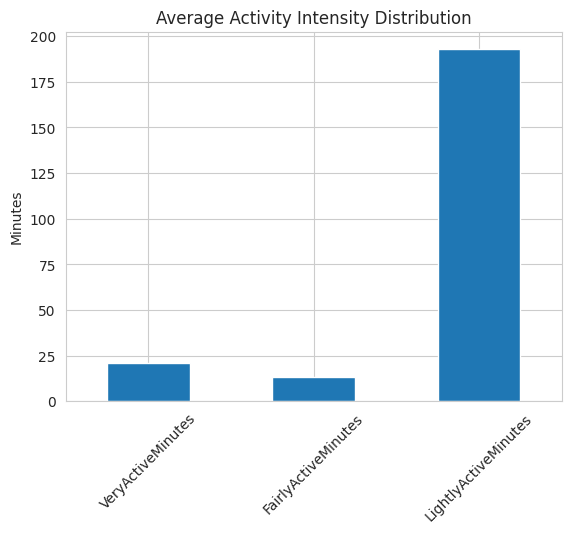

In [34]:
intensity_avg = df[['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes']].mean()

plt.figure()
intensity_avg.plot(kind='bar')
plt.title("Average Activity Intensity Distribution")
plt.ylabel("Minutes")
plt.xticks(rotation=45)
plt.show()

The majority of activity falls under light intensity.

Approximately 85% of total active time consists of light activity,
while very active minutes contribute a small portion.

This indicates that users engage more in casual movement
rather than structured or high-intensity workouts.

## 6. Correlation Analysis

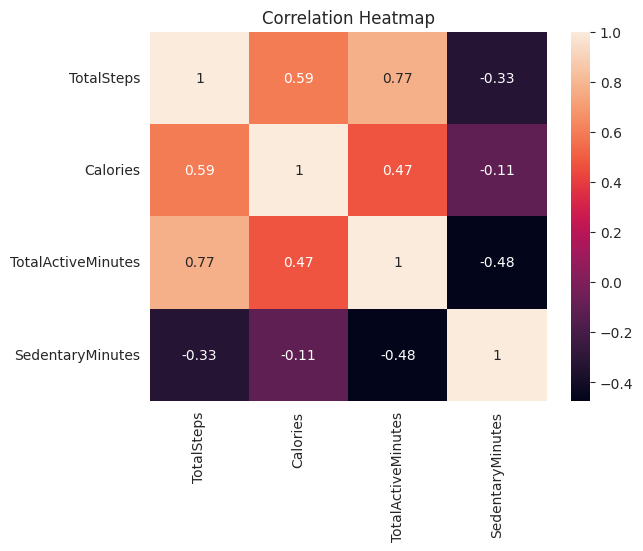

In [35]:
correlation = df[['TotalSteps','Calories','TotalActiveMinutes','SedentaryMinutes']].corr()

plt.figure()
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

The heatmap reveals:

- A strong positive correlation (0.77) between total steps and active minutes.
- A moderate positive correlation (0.59) between steps and calories burned.
- A negative correlation between active minutes and sedentary minutes.

This confirms that increased movement significantly impacts calorie expenditure.

## 7. Activity Level Segmentation

In [36]:
def get_activity_level(total_steps):
    if total_steps < 5000:
        return 'Low Activity'
    elif 5000 <= total_steps < 10000:
        return 'Moderate Activity'
    else:
        return 'High Activity'

df['ActivityLevel'] = df['TotalSteps'].apply(get_activity_level)

segmentation = df.groupby('ActivityLevel')[['TotalSteps','Calories']].mean().round(2)
segmentation

,TotalSteps,Calories
ActivityLevel,,
High Activity,13337.40,2743.58
Low Activity,2128.17,1806.81
Moderate Activity,7465.78,2355.16


High activity users burn significantly more calories than low activity users.

The difference in calorie expenditure between low and high activity groups
demonstrates the strong impact of movement intensity on energy expenditure.

## 8. Steps vs Calories Relationship

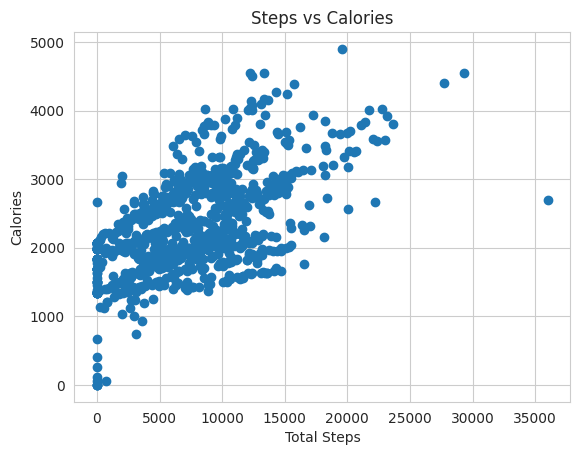

In [37]:
plt.figure()
plt.scatter(df['TotalSteps'], df['Calories'])
plt.title("Steps vs Calories")
plt.xlabel("Total Steps")
plt.ylabel("Calories")
plt.show()

The analysis reveals that while users engage in daily movement,
most activity remains light intensity, and sedentary time is significantly high.

There is a clear positive relationship between steps and calorie expenditure.
Increasing movement levels can significantly improve energy burn
and overall engagement.

These findings support the need for strategies that encourage
higher activity intensity and reduce sedentary behavior.

## 9. Average Active Minutes by Weekday

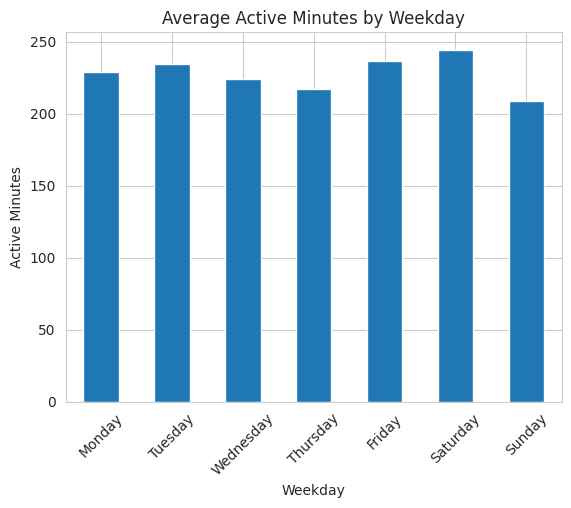

In [38]:
weekday_active = df.groupby('Weekday')['TotalActiveMinutes'].mean().reindex(
    ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
)

plt.figure()
weekday_active.plot(kind='bar')
plt.title("Average Active Minutes by Weekday")
plt.ylabel("Active Minutes")
plt.xticks(rotation=45)
plt.show()

## 10. Business Recommendations

Based on the analysis:

- Target low activity users to increase engagement.
- Introduce Sunday motivation campaigns to reduce inactivity.
- Promote intensity-based challenges.
- Offer premium analytics features for high-activity users.